# VaR y TVaR de la cartera elegida

Calculo el VaR (pérdida diaria que solo se supera en el 5 % o el 1 % de los días peores) y el TVaR (pérdida media en esos días) de la cartera de máximo Sharpe con Z = 0,5, estimada solo con los datos de entrenamiento (2016-2022), y la comparo con la cartera de pesos iguales.

Elijo Z = 0,5 porque fue la única que igualó o superó al máximo Sharpe sin ajustar en las dos particiones del backtest, aunque las diferencias están dentro del error de estimación. Es una candidata razonable, no una ganadora demostrada.

**Contenido:** A. riesgo de cola en 2023-2025 · B. validación con el VaR del entrenamiento · C. volatilidad en entrenamiento y prueba · D. comparación con una normal · E. incertidumbre (bootstrap por bloques) · F. sensibilidad al tamaño de bloque · G. prueba de estrés · conclusiones.

In [26]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.portfolio import (medias_shrinkage, cartera_max_sharpe, var_historico,
                           tvar_historico, excedencias, remuestra_bloques)

precios = pd.read_csv("../data/precios.csv", index_col="Date", parse_dates=True)
rentabilidades = precios.pct_change().dropna()

entrenamiento = rentabilidades.loc["2016":"2022"]
prueba = rentabilidades.loc["2023":"2025"]

tbill = pd.read_csv("../data/DGS3MO.csv", index_col=0, parse_dates=True).iloc[:, 0]
tbill = pd.to_numeric(tbill, errors="coerce")
rf_ent = tbill.loc["2016":"2022"].mean() / 100

print(len(entrenamiento), len(prueba), round(rf_ent, 5))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
1761 752 0.01117


### Pesos de las dos carteras

Recalculo los pesos como en el notebook 06, solo con el entrenamiento (2016-2022) y con `rf_ent`. La cartera de shrinkage (Z = 0,5) se reparte entre GLD (53,9 %) y SPY (46,1 %); la de pesos iguales pone un 16,7 % en cada activo. Después calculo el rendimiento diario de cada cartera en los dos periodos.

In [27]:
cov_ent = entrenamiento.cov().values * 252
mu_z05 = medias_shrinkage(entrenamiento, 0.5, rf_ent).values

pesos = pd.DataFrame({
    "Pesos iguales": np.repeat(1 / 6, 6),
    "Shrinkage Z = 0,5": cartera_max_sharpe(cov_ent, mu_z05, rf_ent),
}, index=entrenamiento.columns)
pesos.round(3)

,Pesos iguales,"Shrinkage Z = 0,5"
AGG,0.167,0.000
EEM,0.167,0.000
EFA,0.167,0.000
GLD,0.167,0.539
SPY,0.167,0.461
VNQ,0.167,0.000


In [28]:
rend_ent = pd.DataFrame({n: entrenamiento.values @ pesos[n].values for n in pesos}, index=entrenamiento.index)
rend_prueba = pd.DataFrame({n: prueba.values @ pesos[n].values for n in pesos}, index=prueba.index)

print(rend_ent.shape, rend_prueba.shape)

(1761, 2) (752, 2)


### A. Riesgo de cola en 2023-2025 (descriptivo)

VaR y TVaR históricos al 95 % y al 99 %, calculados con los rendimientos diarios del periodo de prueba. Son pérdidas diarias en tanto por uno (0,0107 = 1,07 %). Los rendimientos de cada cartera suponen un rebalanceo diario a los pesos fijos, sin costes de transacción.

In [29]:
niveles = [0.95, 0.99]
tabla_a = pd.DataFrame({
    (n, f"{int(q*100)} %"): {"VaR": var_historico(rend_prueba[n], q),
                              "TVaR": tvar_historico(rend_prueba[n], q)}
    for n in rend_prueba for q in niveles
}).T
tabla_a.round(4)

VaR    TVaR
Pesos iguales     95 %  0.0101  0.0141
                  99 %  0.0152  0.0219
Shrinkage Z = 0,5 95 %  0.0107  0.0157
                  99 %  0.0182  0.0260

**Resultado.** En la muestra, la cartera de shrinkage tiene un VaR y un TVaR algo mayores que la de pesos iguales en los dos niveles (por ejemplo, VaR al 99 % de 1,82 % frente a 1,52 %, y TVaR al 99 % de 2,60 % frente a 2,19 %). Son estimaciones con mucha incertidumbre: más abajo mido cuánto de esa diferencia se distingue del ruido.

### B. Validación: ¿se cumple en la prueba el VaR del entrenamiento?

Estimo el VaR con 2016-2022 y cuento los días de 2023-2025 en que la pérdida lo supera. Si el VaR fuera perfecto, esperaría un 5 % de días al nivel del 95 % y un 1 % al del 99 % (37,6 y 7,5 de 752 días).

In [30]:
filas = {}
for n in rend_ent:
    for q in niveles:
        var_ent = var_historico(rend_ent[n], q)
        filas[(n, f"{int(q*100)} %")] = {
            "VaR (entrenamiento)": var_ent,
            "Excedencias observadas": excedencias(rend_prueba[n], var_ent),
            "Excedencias esperadas": (1 - q) * len(rend_prueba),
        }
pd.DataFrame(filas).T

VaR (entrenamiento)  Excedencias observadas  \
Pesos iguales     95 %             0.011336                    25.0   
                  99 %             0.019552                     5.0   
Shrinkage Z = 0,5 95 %             0.011041                    34.0   
                  99 %             0.020780                     5.0   

                        Excedencias esperadas  
Pesos iguales     95 %                  37.60  
                  99 %                   7.52  
Shrinkage Z = 0,5 95 %                  37.60  
                  99 %                   7.52

**Resultado.** La cartera de shrinkage cumple lo esperado: 34 excedencias frente a 37,6 al 95 %, y 5 frente a 7,5 al 99 %. La de pesos iguales tiene 25 al 95 %, por debajo de lo esperado (la desviación típica del conteo es de unas 6 excedencias, así que son ≈ 2 desviaciones por debajo): su VaR resultó prudente y sobreestimó el riesgo. Al 99 %, con solo 5 excedencias, no se puede concluir nada. La sección C comprueba si el periodo de prueba fue más tranquilo que el de entrenamiento.

### C. Volatilidad en entrenamiento y en prueba

Compruebo si el periodo de prueba fue más tranquilo que el de entrenamiento, para entender las excedencias de la parte B.

In [31]:
pd.DataFrame({"Vol. entrenamiento": rend_ent.std() * np.sqrt(252),
              "Vol. prueba": rend_prueba.std() * np.sqrt(252)}).round(3)

,Vol. entrenamiento,Vol. prueba
Pesos iguales,0.129,0.105
"Shrinkage Z = 0,5",0.118,0.117


**Resultado.** En pesos iguales la volatilidad anual baja de 12,9 % (entrenamiento) a 10,5 % (prueba); el entrenamiento incluye la caída de marzo de 2020. Eso explica probablemente que su VaR saliera alto y hubiera pocas excedencias. En shrinkage la volatilidad es casi igual en los dos periodos (11,8 % y 11,7 %) y las excedencias salen las esperadas, lo que es coherente.

### D. ¿La cola es más gruesa que la de una normal?

Comparo el VaR histórico con el que daría una distribución normal con la misma media y desviación típica (periodo de prueba). Después miro el histograma de la cartera de shrinkage.

In [32]:
filas = {}
for n in rend_prueba:
    for q in niveles:
        mu, sigma = rend_prueba[n].mean(), rend_prueba[n].std()
        filas[(n, f"{int(q*100)} %")] = {
            "VaR histórico": var_historico(rend_prueba[n], q),
            "VaR normal": -mu + norm.ppf(q) * sigma,
        }
pd.DataFrame(filas).T.round(4)

VaR histórico  VaR normal
Pesos iguales     95 %         0.0101      0.0102
                  99 %         0.0152      0.0147
Shrinkage Z = 0,5 95 %         0.0107      0.0111
                  99 %         0.0182      0.0161

**Resultado.** Al 95 % los dos coinciden (1,01 % frente a 1,02 % en pesos iguales; 1,07 % frente a 1,11 % en shrinkage). Al 99 % el histórico supera al normal en shrinkage (1,82 % frente a 1,61 %) y es casi igual en pesos iguales (1,52 % frente a 1,47 %). Esa diferencia es pequeña comparada con la incertidumbre que mido en la sección E, así que el VaR al 99 % por sí solo no demuestra que la cola sea más gruesa que la normal. El TVaR es más informativo, y lo comparo con intervalos en esa misma sección.

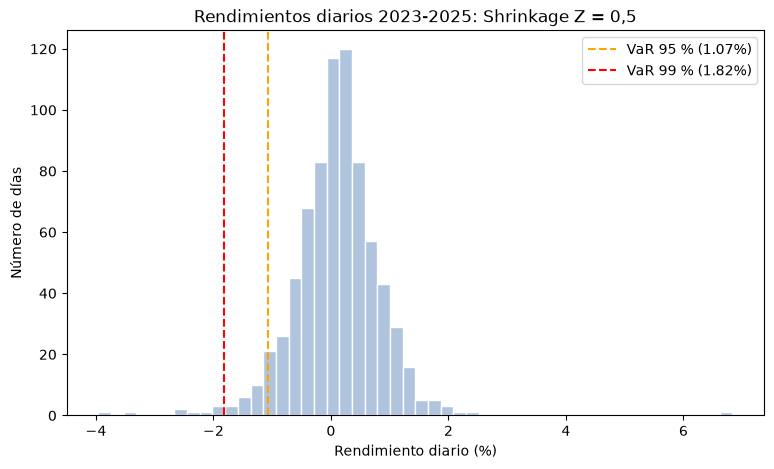

In [33]:
n = "Shrinkage Z = 0,5"
r = rend_prueba[n]

var95 = var_historico(r, 0.95)
var99 = var_historico(r, 0.99)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(r * 100, bins=50, color="lightsteelblue", edgecolor="white")
ax.axvline(-var95 * 100, color="orange", linestyle="--", label=f"VaR 95 % ({var95:.2%})")
ax.axvline(-var99 * 100, color="red", linestyle="--", label=f"VaR 99 % ({var99:.2%})")
ax.set_xlabel("Rendimiento diario (%)")
ax.set_ylabel("Número de días")
ax.set_title(f"Rendimientos diarios 2023-2025: {n}")
ax.legend()
plt.show()

La mayoría de los días se concentra entre −1 % y +1 %. Por construcción, a la izquierda de la línea naranja caen unos 38 días (el 5 % de 752) y a la de la roja unos 8 (el 1 %). Lo informativo es lo que hay más allá: hay días aislados cerca de −4 %, que con una desviación típica diaria de ≈ 0,74 % son más de 5 desviaciones típicas, algo que una normal prácticamente no permite en 752 días. Esto apunta a una cola gruesa, que contrasto con intervalos en la sección E.

### E. Incertidumbre de las estimaciones (bootstrap por bloques)

Con 752 días, el VaR y el TVaR son estimaciones, no valores exactos, sobre todo al 99 %, que depende de unos 7 u 8 días. Remuestreo los días de la prueba en bloques de 21 (como en el notebook 05) y, en cada remuestreo, calculo el VaR y el TVaR históricos y también los que daría una normal con la media y la desviación típica de ese remuestreo. Me quedo con los percentiles 5 y 95 (intervalo del 90 %). Las dos carteras se remuestrean con los mismos días, así que puedo medir la diferencia entre ellas y la diferencia entre el histórico y el normal.

In [34]:
rng = np.random.default_rng(42)
datos = rend_prueba.values
n_rep = 1000

res = []
for _ in range(n_rep):
    m = remuestra_bloques(datos, 21, rng)
    fila = {}
    for j, n in enumerate(rend_prueba.columns):
        mu, sigma = m[:, j].mean(), m[:, j].std(ddof=1)
        for q in niveles:
            nivel = f"{int(q*100)} %"
            z = norm.ppf(q)
            fila[(n, nivel, "VaR")] = var_historico(m[:, j], q)
            fila[(n, nivel, "TVaR")] = tvar_historico(m[:, j], q)
            fila[(n, nivel, "VaR normal")] = -mu + z * sigma
            fila[(n, nivel, "TVaR normal")] = -mu + sigma * norm.pdf(z) / (1 - q)
    res.append(fila)

boot = pd.DataFrame(res)
boot.columns = pd.MultiIndex.from_tuples(boot.columns)
print(boot.shape)

(1000, 16)


In [35]:
resumen = boot.quantile([0.05, 0.5, 0.95]).T
resumen.columns = ["Percentil 5", "Mediana", "Percentil 95"]
resumen.round(4)

Percentil 5  Mediana  Percentil 95
Pesos iguales     95 % VaR               0.0093   0.0102        0.0112
                       TVaR              0.0119   0.0141        0.0170
                       VaR normal        0.0087   0.0102        0.0122
                       TVaR normal       0.0111   0.0129        0.0154
                  99 % VaR               0.0135   0.0152        0.0206
                       TVaR              0.0156   0.0213        0.0277
                       VaR normal        0.0126   0.0146        0.0174
                       TVaR normal       0.0146   0.0168        0.0201
Shrinkage Z = 0,5 95 % VaR               0.0092   0.0107        0.0115
                       TVaR              0.0132   0.0154        0.0180
                       VaR normal        0.0094   0.0110        0.0129
                       TVaR normal       0.0120   0.0141        0.0164
                  99 % VaR               0.0147   0.0178        0.0228
                       TVaR              0.0185   0.0246        0.0319
                       VaR normal        0.0137   0.0160        0.0187
                       TVaR normal       0.0158   0.0185        0.0215

**Resultado.** Los intervalos son anchos, sobre todo al 99 %: el VaR histórico de shrinkage va de 1,47 % a 2,28 % y su TVaR de 1,85 % a 3,19 %. Los intervalos de las dos carteras se solapan mucho. Los de la normal son más estrechos y quedan por debajo del histórico en el TVaR: por ejemplo, el TVaR al 99 % de shrinkage tiene una mediana de 1,85 % con la normal y de 2,46 % con el histórico.

#### Diferencia entre carteras

En cada remuestreo calculo la diferencia entre el VaR (o el TVaR) de shrinkage y el de pesos iguales. Como las dos carteras usan los mismos días, la diferencia está bien medida. Si el intervalo incluye el 0, no puedo afirmar que una cartera tenga más riesgo de cola que la otra.

In [36]:
filas = {}
for nivel in ["95 %", "99 %"]:
    for medida in ["VaR", "TVaR"]:
        dif = (boot[("Shrinkage Z = 0,5", nivel, medida)]
               - boot[("Pesos iguales", nivel, medida)])
        filas[(nivel, medida)] = {
            "Diferencia mediana": dif.median(),
            "Percentil 5": dif.quantile(0.05),
            "Percentil 95": dif.quantile(0.95),
            "% de remuestreos con shrinkage > iguales": (dif > 0).mean(),
        }
pd.DataFrame(filas).T.round(4)

Diferencia mediana  Percentil 5  Percentil 95  \
95 % VaR               0.0004      -0.0006        0.0013   
     TVaR              0.0013      -0.0000        0.0026   
99 % VaR               0.0021      -0.0008        0.0046   
     TVaR              0.0031       0.0001        0.0071   

           % de remuestreos con shrinkage > iguales  
95 % VaR                                      0.745  
     TVaR                                     0.948  
99 % VaR                                      0.886  
     TVaR                                     0.957

**Resultado.** En el VaR, el intervalo de la diferencia (shrinkage − pesos iguales) incluye el 0 en los dos niveles, así que no puedo afirmar que shrinkage tenga un VaR mayor. En el TVaR hay una señal débil: al 99 % el intervalo queda por encima de 0 (de 0,01 a 0,71 puntos porcentuales) y al 95 % llega justo hasta el 0 (de 0,00 a 0,26); shrinkage tiene un TVaR mayor en el 95,7 % y en el 94,8 % de los remuestreos. Es una lectura, no una prueba (intervalo del 90 %). El bootstrap mide la incertidumbre de estimar con 752 días, no si 2026-2030 se parecerá a 2023-2025.

#### Histórico frente a normal, con intervalos

En cada remuestreo calculo la diferencia entre el VaR (o el TVaR) histórico y el de una normal con la misma media y desviación típica. Si el intervalo de la diferencia queda por encima de 0, el histórico supera a la normal más de lo que explica el ruido de la muestra.

In [37]:
filas = {}
for n in rend_prueba.columns:
    for nivel in ["95 %", "99 %"]:
        for medida in ["VaR", "TVaR"]:
            dif = boot[(n, nivel, medida)] - boot[(n, nivel, medida + " normal")]
            filas[(n, nivel, medida)] = {
                "Diferencia mediana": dif.median(),
                "Percentil 5": dif.quantile(0.05),
                "Percentil 95": dif.quantile(0.95),
                "% remuestreos histórico > normal": (dif > 0).mean(),
            }
pd.DataFrame(filas).T.round(4)

Diferencia mediana  Percentil 5  Percentil 95  \
Pesos iguales     95 % VaR              -0.0001      -0.0014        0.0010   
                       TVaR              0.0012       0.0003        0.0022   
                  99 % VaR               0.0013      -0.0004        0.0042   
                       TVaR              0.0044       0.0005        0.0085   
Shrinkage Z = 0,5 95 % VaR              -0.0005      -0.0022        0.0007   
                       TVaR              0.0014       0.0002        0.0024   
                  99 % VaR               0.0021      -0.0002        0.0054   
                       TVaR              0.0060       0.0021        0.0106   

                             % remuestreos histórico > normal  
Pesos iguales     95 % VaR                              0.474  
                       TVaR                             0.987  
                  99 % VaR                              0.892  
                       TVaR                             0.979  
Shrinkage Z = 0,5 95 % VaR                              0.283  
                       TVaR                             0.968  
                  99 % VaR                              0.938  
                       TVaR                             0.997

**Resultado.** El VaR no distingue el histórico del normal: en las dos carteras y los dos niveles el intervalo de la diferencia incluye el 0 (el caso más cercano es el VaR al 99 % de shrinkage, de −0,02 a +0,54 puntos porcentuales). El TVaR sí: en las cuatro combinaciones el intervalo queda por encima de 0. El TVaR histórico supera al normal en torno a un 9 % al 95 % y a un 27 % (pesos iguales: 2,13 % frente a 1,68 %) y un 33 % (shrinkage: 2,46 % frente a 1,85 %) al 99 %.

Es el patrón de una cola gruesa: la normal acierta dónde empieza la cola, pero subestima cuánto se pierde una vez que se pasa ese punto. Matices: los intervalos son del 90 %; el percentil 5 queda por encima de 0 en las cuatro combinaciones del TVaR, pero tres de ellas por muy poco (menos de 0,05 puntos porcentuales) y solo shrinkage al 99 % con holgura (desde 0,21); y las cuatro comparaciones no son independientes (las carteras comparten los días y SPY, y los dos niveles comparten los días malos). La sección F comprueba si el resultado depende del tamaño de bloque.

### F. Sensibilidad al tamaño de bloque

Repito la comparación más importante (TVaR al 99 %, histórico − normal) con bloques de 1, 5, 10, 21 y 42 días (500 remuestreos cada uno). El bloque de 1 día supone días independientes; los bloques largos conservan más dependencia entre días.

In [38]:
q99 = 0.99
z99 = norm.ppf(q99)

filas = {}
for b in [1, 5, 10, 21, 42]:
    rng = np.random.default_rng(42)
    difs = []
    for _ in range(500):
        m = remuestra_bloques(datos, b, rng)
        fila = []
        for j in range(m.shape[1]):
            mu, sigma = m[:, j].mean(), m[:, j].std(ddof=1)
            tvar_normal = -mu + sigma * norm.pdf(z99) / (1 - q99)
            fila.append(tvar_historico(m[:, j], q99) - tvar_normal)
        difs.append(fila)
    difs = pd.DataFrame(difs, columns=rend_prueba.columns)
    for n in difs:
        filas[(n, f"Bloque {b}")] = {"Percentil 5": difs[n].quantile(0.05),
                                      "Mediana": difs[n].median(),
                                      "Percentil 95": difs[n].quantile(0.95)}
pd.DataFrame(filas).T.round(4)

,,Percentil 5,Mediana,Percentil 95
Pesos iguales,Bloque 1,0.0001,0.0043,0.0094
"Shrinkage Z = 0,5",Bloque 1,0.0016,0.0067,0.0118
Pesos iguales,Bloque 5,0.0004,0.0043,0.0096
"Shrinkage Z = 0,5",Bloque 5,0.0019,0.0065,0.0116
Pesos iguales,Bloque 10,0.0003,0.0045,0.0091
"Shrinkage Z = 0,5",Bloque 10,0.0015,0.0061,0.0110
Pesos iguales,Bloque 21,0.0005,0.0044,0.0087
"Shrinkage Z = 0,5",Bloque 21,0.0021,0.0060,0.0106
Pesos iguales,Bloque 42,0.0005,0.0042,0.0082
"Shrinkage Z = 0,5",Bloque 42,0.0023,0.0057,0.0099


**Resultado.** El percentil 5 de la diferencia queda por encima de 0 en las diez filas, así que el resultado no depende del tamaño de bloque. En shrinkage es holgado (de 0,15 a 0,23 puntos porcentuales); en pesos iguales es muy ajustado (de 0,01 a 0,05), sobre todo con bloque 1. Las medianas casi no cambian (0,42-0,45 puntos en pesos iguales; 0,57-0,67 en shrinkage) y los intervalos no se ensanchan con bloques largos. Con bloques de 42 días solo hay 17 bloques, así que no hay que sobreinterpretar.

### G. Prueba de estrés: los peores días de 2016-2025

Aplico los pesos de 2016-2022 a toda la muestra para ver qué habría pasado en los peores momentos. No es un resultado fuera de la muestra (2016-2022 es el periodo con el que se eligieron los pesos): es un "qué habría pasado si". Los rendimientos de cada cartera suponen un rebalanceo diario a los pesos fijos, sin costes de transacción.

In [39]:
rend_total = pd.DataFrame({n: rentabilidades.values @ pesos[n].values for n in pesos},
                          index=rentabilidades.index)

print(rend_total.nsmallest(5, "Shrinkage Z = 0,5").round(4))   # 5 peores días
covid = rend_total.loc["2020-02-19":"2020-03-23"]
print(((1 + covid).prod() - 1).round(3))                       # caída acumulada del crash
print((rentabilidades.loc["2025-10-21"] * 100).round(2))       # rendimientos (%) de cada activo ese día

            Pesos iguales  Shrinkage Z = 0,5
Date                                        
2020-03-12        -0.0811            -0.0656
2020-03-16        -0.0849            -0.0566
2025-04-04        -0.0410            -0.0396
2020-03-09        -0.0501            -0.0351
2025-10-21        -0.0141            -0.0347
Pesos iguales       -0.247
Shrinkage Z = 0,5   -0.178
dtype: float64
AGG    0.10
EEM   -1.11
EFA   -0.73
GLD   -6.43
SPY   -0.00
VNQ   -0.28
Name: 2025-10-21 00:00:00, dtype: float64


**Resultado.** Los cinco peores días de shrinkage son tres de marzo de 2020 (hasta −6,6 %) y dos de 2025 (−4,0 % el 4 de abril y −3,5 % el 21 de octubre). En la caída del Covid (19 de febrero a 23 de marzo de 2020), pesos iguales perdió un 24,7 % y shrinkage un 17,8 %: ante un desplome de la bolsa, tener solo oro y SPY protegió más que repartir a partes iguales. El 21 de octubre de 2025 pasa lo contrario: shrinkage perdió un 3,5 % y pesos iguales un 1,4 %, porque ese día GLD cayó un 6,43 % mientras SPY quedó plano (0,00 %). Cada cartera es vulnerable a shocks distintos, y la concentrada lo es más cuando el shock afecta a uno de sus dos activos. Son resultados "qué habría pasado si", no fuera de la muestra: los pesos se eligieron con datos que incluyen 2020.

## Conclusiones

- **Riesgo de cola.** En 2023-2025 la cartera de shrinkage (Z = 0,5; 54 % GLD y 46 % SPY) tiene VaR y TVaR mayores que la de pesos iguales en la muestra (VaR al 99 % de 1,82 % frente a 1,52 %). Con el bootstrap, solo el TVaR muestra una señal (al 99 % el intervalo de la diferencia queda por encima de 0; al 95 % llega justo al 0); en el VaR la diferencia no se distingue del ruido. Shrinkage tiende a tener más riesgo de cola, pero no está demostrado. Su mejor Sharpe del notebook 06 viene de la rentabilidad, no de un menor riesgo.
- **Validación.** Con el VaR estimado en 2016-2022, shrinkage cumple las excedencias esperadas (34 de 37,6 al 95 %; 5 de 7,5 al 99 %). Pesos iguales queda por debajo de lo esperado (25 al 95 %, ≈ 2 desviaciones típicas), probablemente porque el entrenamiento incluye marzo de 2020 y fue más volátil que la prueba (volatilidad anual de 12,9 % frente a 10,5 %).
- **Cola gruesa.** El VaR histórico no se distingue del de una normal con la misma media y desviación típica (los intervalos de la diferencia incluyen el 0). El TVaR sí: en las dos carteras y los dos niveles el TVaR histórico supera al normal (un 9 % al 95 % y un 27-33 % al 99 %) y el percentil 5 de la diferencia queda por encima de 0, incluso con bloques de 1 a 42 días. La evidencia es moderada: clara en shrinkage al 99 %, muy ajustada en el resto. La normal acierta dónde empieza la cola, pero subestima la gravedad de los peores días.
- **Estrés.** El riesgo depende del tipo de shock: en el Covid, pesos iguales perdió más (−24,7 % frente a −17,8 %), y el 21 de octubre de 2025 perdió más shrinkage (−3,5 % frente a −1,4 %), por una caída del oro del 6,43 %.
- **Limitaciones.** Solo tres años de prueba; con 5 excedencias al 99 % no se puede concluir; intervalos del 90 %, anchos y aproximados (≈ 35 bloques); las comparaciones del bootstrap no son independientes entre sí; no he contrastado que las excedencias sean independientes entre días; el VaR histórico supone que el futuro se parece al pasado; los pesos se estiman una sola vez (2016-2022) y los rendimientos suponen rebalanceo diario sin costes de transacción.